# ROGII Wellbore Geology - LSTM Inference

Load the trained BiLSTM, predict TVT for test wells, generate submission.

**Features (6):** `MD, X, Y, Z, GR, TVT_input`

**Runtime**: Kaggle GPU - **Author**: Samir Attrah

In [1]:
# Cell 1: Environment & Imports
import os
os.environ["KERAS_BACKEND"] = "jax"

import keras
import jax.numpy as jnp
import numpy as np
import polars as pl
import glob, pickle, warnings
warnings.filterwarnings("ignore")
print(f"Keras: {keras.__version__}, Backend: {keras.backend.backend()}")


Keras: 3.10.0, Backend: jax


In [2]:
# Cell 2: Auto-detect dataset path

def find_data_dir():
    """Searches common Kaggle mount points for the ROGII dataset.

    Returns:
        Absolute path to the dataset root directory.

    Raises:
        FileNotFoundError: If no valid dataset is found.
    """
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]

    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                full = os.path.join(scan_root, entry)
                if os.path.isdir(full) and full not in candidates:
                    candidates.append(full)

    print("Searching for ROGII test dataset...")
    for path in candidates:
        if not os.path.isdir(path):
            continue

        contents = os.listdir(path)
        has_test = "test" in contents and os.path.isdir(os.path.join(path, "test"))
        
        if has_test:
            n_test = len(glob.glob(os.path.join(path, "test", "*__horizontal_well.csv")))
            if n_test > 0:
                print(f"  V Using {path} (found {n_test} test wells)")
                return path

    raise FileNotFoundError("Could not find ROGII dataset with 'test' directory.")

DATA_DIR = find_data_dir()


Searching for ROGII test dataset...
  V Using /kaggle/input/competitions/rogii-wellbore-geology-prediction (found 3 test wells)


In [3]:
# Cell 3: Auto-detect model artifact

def find_model_dir():
    """Searches Kaggle input paths for the trained model artifact.

    Returns:
        Path to directory containing lstm_tvt_model.keras.

    Raises:
        FileNotFoundError: If no model artifact found.
    """
    print("Searching for model artifact in input directory...")

    # Prioritize /kaggle/input and /kaggle/input/competitions
    candidates = []
    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                candidates.append(os.path.join(scan_root, entry))
    
    # Local fallbacks (keep them but prioritize Kaggle inputs)
    candidates += [
        "/kaggle/input/models/samerattrah/rogii-21-05/keras/default/5",
        "/tmp/rogii_output",
    ]

    for path in candidates:
        if not os.path.isdir(path):
            continue
        keras_files = glob.glob(os.path.join(path, "*.keras"))
        if keras_files:
            print(f"  -> {path}")
            print(f"    .keras files: {[os.path.basename(f) for f in keras_files]}")
            print(f"  V Using this as MODEL_DIR")
            return path
        # Check one level deeper (often datasets are nested)
        try:
            for sub in os.listdir(path):
                sub_path = os.path.join(path, sub)
                if os.path.isdir(sub_path):
                    keras_sub = glob.glob(os.path.join(sub_path, "*.keras"))
                    if keras_sub:
                        print(f"  -> {sub_path}")
                        return sub_path
        except:
            continue

    raise FileNotFoundError(
        "No model artifact (.keras) found in Kaggle input. Checked candidates."
    )

MODEL_DIR = find_model_dir()


Searching for model artifact in input directory...
  -> /kaggle/input/models/samerattrah/rogii-21-05/keras/default/5
    .keras files: ['lstm_tvt_model.keras']
  V Using this as MODEL_DIR


In [4]:
# Cell 4: Configuration

OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle") else "/tmp/rogii_output"
os.makedirs(OUT_DIR, exist_ok=True)

CONFIG = {
    "data_dir": DATA_DIR,
    "model_path": os.path.join(MODEL_DIR, "lstm_tvt_model.keras"),
    "scaler_path": os.path.join(MODEL_DIR, "scaler_params.pkl"),
    "submission_path": os.path.join(OUT_DIR, "submission.csv"),
    "window_size": 3,
}

FEATURE_COLS = [
    "MD", "X", "Y", "Z", "GR", "TVT_input",
]

print(f"Data dir      : {CONFIG['data_dir']}")
print(f"Model path    : {CONFIG['model_path']}")
print(f"Scaler path   : {CONFIG['scaler_path']}")
print(f"Submission out: {CONFIG['submission_path']}")


Data dir      : /kaggle/input/competitions/rogii-wellbore-geology-prediction
Model path    : /kaggle/input/models/samerattrah/rogii-21-05/keras/default/5/lstm_tvt_model.keras
Scaler path   : /kaggle/input/models/samerattrah/rogii-21-05/keras/default/5/scaler_params.pkl
Submission out: /kaggle/working/submission.csv


In [5]:
# Cell 5: Load model & scaler

print("Loading model...")
model = keras.saving.load_model(CONFIG["model_path"])
print(f"✓ Model loaded: {model.name}, params={model.count_params():,}")
model.summary()

print("\nLoading scaler...")
with open(CONFIG["scaler_path"], "rb") as f:
    scaler = pickle.load(f)
print(f"✓ Scaler loaded: {list(scaler.keys())}")
print(f"  Target mean={scaler['target_mean']:.2f}, std={scaler['target_std']:.2f}")


Loading model...


2026-05-24 11:41:38.105866: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779622898.287523      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779622898.352145      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779622898.891240      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779622898.891276      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779622898.891279      57 computation_placer.cc:177] computation placer alr

✓ Model loaded: BiLSTM_TVT, params=227,617


Model: "BiLSTM_TVT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm1 (Bidirectional)         │ (None, 6, 128)         │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm2 (Bidirectional)         │ (None, 6, 64)          │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm3 (Bidirectional)         │ (None, 6, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm4 (Bidirectional)         │ (None, 6, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm5 (Bidirectional)         │ (None, 6, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm6 (Bidirectional)         │ (None, 6, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm7 (Bidirectional)         │ (None, 6, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm8 (Bidirectional)         │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,853 (2.60 MB)

 Trainable params: 227,617 (889.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 455,236 (1.74 MB)


Loading scaler...
✓ Scaler loaded: ['feat_mean', 'feat_std', 'target_mean', 'target_std', 'feature_cols']
  Target mean=11493.00, std=636.86


In [6]:
# Cell 6: Preprocessing (identical to training)

def preprocess(df):
    """Same preprocessing pipeline as training notebook."""
    for col in ["GR", "TVT_input"]:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col).interpolate()
                  .fill_null(strategy="forward").fill_null(strategy="backward")
                  .fill_null(0.0)
            )
    return df

print("V Preprocessing pipeline defined.")


V Preprocessing pipeline defined.


In [7]:
# Cell 7: Load submission template & predict

sample_sub = pl.read_csv(os.path.join(CONFIG["data_dir"], "sample_submission.csv"))
sample_sub = sample_sub.with_columns([
    pl.col("id").str.extract(r"^(.+)_(\d+)$", 1).alias("well_id"),
    pl.col("id").str.extract(r"^(.+)_(\d+)$", 2).cast(pl.Int64).alias("row_idx"),
])
print(f"Sample submission: {sample_sub.shape[0]} rows")
print(f"Wells in submission: {sample_sub['well_id'].unique().to_list()}")

test_ids = sorted(
    os.path.basename(f).split("__")[0]
    for f in glob.glob(os.path.join(CONFIG["data_dir"], "test", "*__horizontal_well.csv"))
)
print(f"Test well files found: {test_ids}")

def predict_well(model, df, scaler, ws):
    """Predict TVT for every row using sliding windows."""
    feats = np.nan_to_num(df.select(FEATURE_COLS).to_numpy().astype(np.float32))
    feats_n = (feats - scaler["feat_mean"]) / scaler["feat_std"]
    n = len(feats_n)
    preds = np.full(n, np.nan, dtype=np.float32)
    starts = list(range(0, n - ws))
    if not starts:
        return preds
    X = np.stack([feats_n[s:s+ws] for s in starts])
    yn = model.predict(X, batch_size=16, verbose=0).ravel()
    yp = yn * scaler["target_std"] + scaler["target_mean"]
    for i, s in enumerate(starts):
        preds[s + ws - 1] = yp[i]
    fv = ws - 1
    if fv < n and not np.isnan(preds[fv]):
        preds[:fv] = preds[fv]
    return preds

all_preds = {}
for wid in test_ids:
    print(f"\nPredicting well: {wid}")
    df = preprocess(pl.read_csv(
        os.path.join(CONFIG["data_dir"], "test", f"{wid}__horizontal_well.csv"),
        infer_schema_length=10000))
    print(f"  Loaded {len(df)} rows, columns: {df.columns}")
    all_preds[wid] = predict_well(model, df, scaler, CONFIG["window_size"])
    valid = np.sum(~np.isnan(all_preds[wid]))
    print(f"  Predicted {valid}/{len(all_preds[wid])} rows, "
          f"TVT range: [{np.nanmin(all_preds[wid]):.1f}, {np.nanmax(all_preds[wid]):.1f}]")


Sample submission: 14151 rows
Wells in submission: ['000d7d20', '00e12e8b', '00bbac68']
Test well files found: ['000d7d20', '00bbac68', '00e12e8b']

Predicting well: 000d7d20
  Loaded 5278 rows, columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  Predicted 5277/5278 rows, TVT range: [11136.7, 11537.5]

Predicting well: 00bbac68
  Loaded 7559 rows, columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  Predicted 7558/7559 rows, TVT range: [11254.7, 11840.1]

Predicting well: 00e12e8b
  Loaded 6384 rows, columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
  Predicted 6383/6384 rows, TVT range: [10968.6, 11314.1]


In [8]:
# Cell 8: Build, validate & save submission

rows = []
for r in sample_sub.iter_rows(named=True):
    wid, idx = r["well_id"], r["row_idx"]
    arr = all_preds.get(wid)
    val = float(arr[idx]) if arr is not None and idx < len(arr) and not np.isnan(arr[idx]) else 0.0
    rows.append({"id": r["id"], "tvt": val})

submission = pl.DataFrame(rows)
assert submission.shape[0] == sample_sub.shape[0], "Row count mismatch!"
assert set(submission["id"].to_list()) == set(sample_sub["id"].to_list()), "ID mismatch!"

submission.select(["id", "tvt"]).write_csv(CONFIG["submission_path"])
print(f"\n✅ Submission saved: {CONFIG['submission_path']}")
print(f"   Rows: {submission.shape[0]}")
print(f"   TVT mean={submission['tvt'].mean():.2f}, std={submission['tvt'].std():.2f}")
print(submission.head(10))



✅ Submission saved: /kaggle/working/submission.csv
   Rows: 14151
   TVT mean=11554.88, std=274.93
shape: (10, 2)
┌───────────────┬──────────────┐
│ id            ┆ tvt          │
│ ---           ┆ ---          │
│ str           ┆ f64          │
╞═══════════════╪══════════════╡
│ 000d7d20_1442 ┆ 11496.397461 │
│ 000d7d20_1443 ┆ 11496.402344 │
│ 000d7d20_1444 ┆ 11496.408203 │
│ 000d7d20_1445 ┆ 11496.413086 │
│ 000d7d20_1446 ┆ 11496.517578 │
│ 000d7d20_1447 ┆ 11496.483398 │
│ 000d7d20_1448 ┆ 11496.443359 │
│ 000d7d20_1449 ┆ 11496.448242 │
│ 000d7d20_1450 ┆ 11496.453125 │
│ 000d7d20_1451 ┆ 11496.535156 │
└───────────────┴──────────────┘


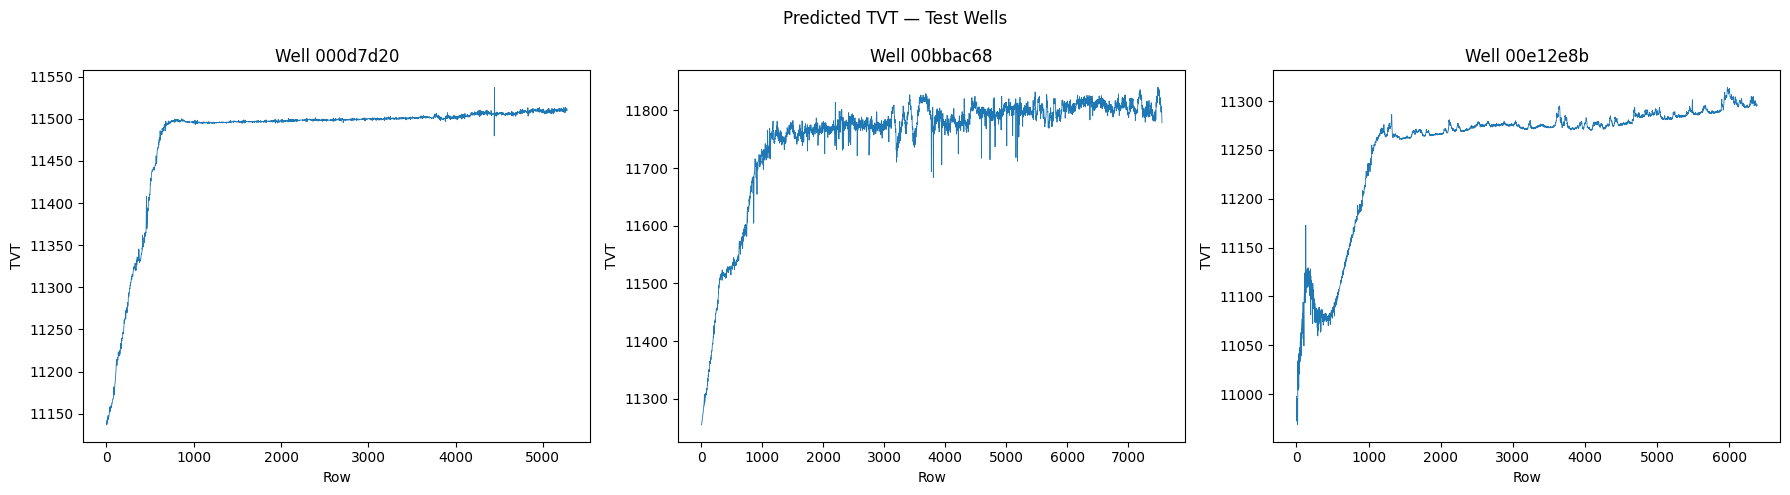

In [9]:
# Cell 9: Visualise predictions

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(test_ids), figsize=(6*len(test_ids), 5), squeeze=False)
for i, wid in enumerate(test_ids):
    axes[0,i].plot(all_preds[wid], lw=0.6)
    axes[0,i].set_title(f"Well {wid}")
    axes[0,i].set_xlabel("Row"); axes[0,i].set_ylabel("TVT")
plt.suptitle("Predicted TVT — Test Wells"); plt.tight_layout(); plt.show()
